In [1]:
# STEP 1: INSTALL AND IMPORT REQUIRED LIBRARIES
# ----------------------------------------------------------------------------

# Install XGBoost (other libraries come pre-installed in Colab)
!pip install xgboost

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
df = pd.read_csv('/content/data_file.csv')

print(f"\n✓ Dataset loaded successfully from: {'/content/data_file.csv'}")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())


✓ Dataset loaded successfully from: /content/data_file.csv
Dataset shape: (62485, 18)

First few rows:
                                            FileName  \
0           0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll   
1       05c8318f98a5d301d80000009c316005.vertdll.dll   
2           06054fba-5619-4a86-a861-ffb0464bef5d.dll   
3        075822ac99a5d301660400009c316005.adhapi.dll   
4  090607dd9ba5d301ca0900009c316005.SensorsNative...   

                            md5Hash  Machine  DebugSize  DebugRVA  \
0  79755c51e413ed3c6be4635fd729a6e1      332          0         0   
1  95e19f3657d34a432eada93221b0ea16    34404         84    121728   
2  85c32641d77a54e19ba8ea4ab305c791      332          0         0   
3  62e3b959d982ef534b66f819fe15f085    34404         84     19904   
4  ae38c5f7d313ad0ff3bfb8826476767f    34404         84     97728   

   MajorImageVersion  MajorOSVersion  ExportRVA  ExportSize  IatVRA  \
0                  0               4          0           0    8192   
1 


DATA EXPLORATION

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-

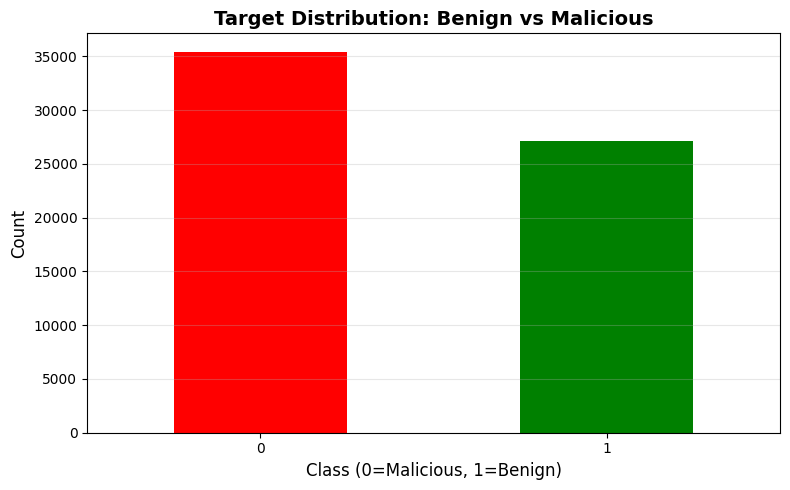

In [3]:
# STEP 3: DATA EXPLORATION AND ANALYSIS
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("DATA EXPLORATION")
print("="*70)

# Display basic information
print("\nDataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("✓ No missing values found")

# Check target distribution
print("\nTarget Distribution:")
target_counts = df['Benign'].value_counts()
print(target_counts)
print(f"\nBenign (1): {target_counts.get(1, 0)} samples ({target_counts.get(1, 0)/len(df)*100:.2f}%)")
print(f"Malicious (0): {target_counts.get(0, 0)} samples ({target_counts.get(0, 0)/len(df)*100:.2f}%)")

# Visualize target distribution
plt.figure(figsize=(8, 5))
target_counts.plot(kind='bar', color=['red', 'green'])
plt.title('Target Distribution: Benign vs Malicious', fontsize=14, fontweight='bold')
plt.xlabel('Class (0=Malicious, 1=Benign)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# STEP 4: DATA PREPROCESSING
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Create a copy of the dataframe
df_processed = df.copy()

# Drop identifier columns (FileName and md5Hash) - NOT used for training
identifier_columns = ['FileName', 'md5Hash']
existing_identifiers = [col for col in identifier_columns if col in df_processed.columns]

if existing_identifiers:
    df_processed = df_processed.drop(columns=existing_identifiers)
    print(f"\n✓ Dropped identifier columns: {existing_identifiers}")

# Handle missing values (if any)
# Strategy: Fill numeric columns with median
if df_processed.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        if df_processed[col].isnull().sum() > 0:
            median_value = df_processed[col].median()
            df_processed[col].fillna(median_value, inplace=True)
            print(f"  - Filled {col} with median: {median_value}")
    print("✓ Missing values handled")
else:
    print("\n✓ No missing values to handle")

# Separate features (X) and target (y)
X = df_processed.drop(columns=['Benign'])
y = df_processed['Benign']

print(f"\n✓ Features (X) shape: {X.shape}")
print(f"✓ Target (y) shape: {y.shape}")
print(f"\nFeature columns used for training:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")



DATA PREPROCESSING

✓ Dropped identifier columns: ['FileName', 'md5Hash']

✓ No missing values to handle

✓ Features (X) shape: (62485, 15)
✓ Target (y) shape: (62485,)

Feature columns used for training:
  1. Machine
  2. DebugSize
  3. DebugRVA
  4. MajorImageVersion
  5. MajorOSVersion
  6. ExportRVA
  7. ExportSize
  8. IatVRA
  9. MajorLinkerVersion
  10. MinorLinkerVersion
  11. NumberOfSections
  12. SizeOfStackReserve
  13. DllCharacteristics
  14. ResourceSize
  15. BitcoinAddresses


In [5]:
# STEP 5: TRAIN-TEST SPLIT
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())


TRAIN-TEST SPLIT

Training set size: 49988 samples
Testing set size: 12497 samples

Training set class distribution:
Benign
0    28294
1    21694
Name: count, dtype: int64

Testing set class distribution:
Benign
0    7073
1    5424
Name: count, dtype: int64


In [6]:
# STEP 6: FEATURE SCALING
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

# Apply StandardScaler for better model performance
# This is especially important for distance-based algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled using StandardScaler (mean=0, std=1)")
print("  Note: Scaler will be saved along with the model for consistency")


FEATURE SCALING

✓ Features scaled using StandardScaler (mean=0, std=1)
  Note: Scaler will be saved along with the model for consistency



MODEL 1: RANDOM FOREST CLASSIFIER

Training Random Forest Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished


✓ Random Forest training completed

----------------------------------------------------------------------
RANDOM FOREST PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy:  0.9964 (99.64%)
Precision: 0.9969
Recall:    0.9948
F1-Score:  0.9958

Confusion Matrix:
[[7056   17]
 [  28 5396]]

Classification Report:
               precision    recall  f1-score   support

Malicious (0)       1.00      1.00      1.00      7073
   Benign (1)       1.00      0.99      1.00      5424

     accuracy                           1.00     12497
    macro avg       1.00      1.00      1.00     12497
 weighted avg       1.00      1.00      1.00     12497



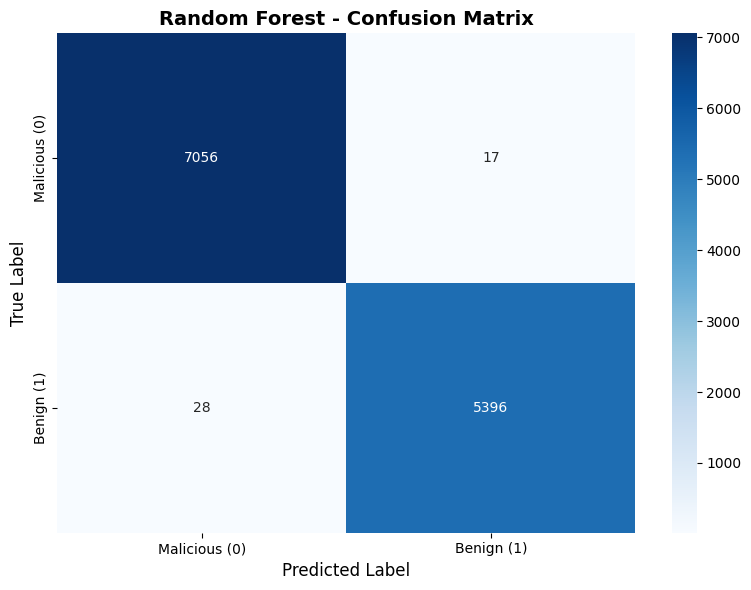


Top 10 Most Important Features (Random Forest):
               Feature  Importance
12  DllCharacteristics    0.233552
1            DebugSize    0.132554
2             DebugRVA    0.124709
8   MajorLinkerVersion    0.116614
4       MajorOSVersion    0.076830
13        ResourceSize    0.072148
0              Machine    0.052556
7               IatVRA    0.043833
11  SizeOfStackReserve    0.039837
10    NumberOfSections    0.038417


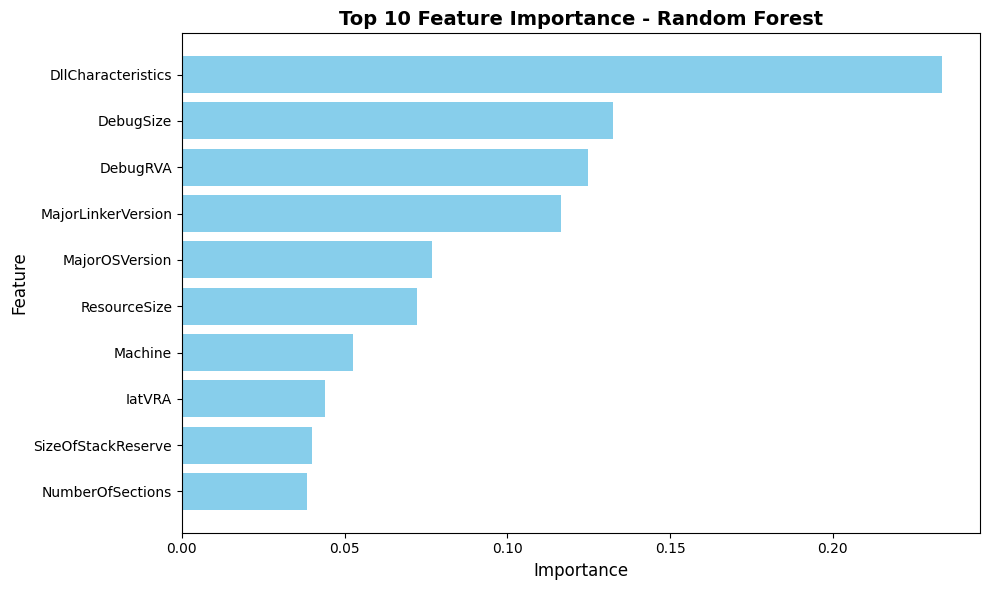

In [7]:
# ----------------------------------------------------------------------------
# STEP 7: MODEL TRAINING - RANDOM FOREST
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*70)

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Maximum depth of trees
    random_state=42,
    n_jobs=-1,             # Use all CPU cores
    verbose=1
)

print("\nTraining Random Forest Classifier...")
rf_model.fit(X_train_scaled, y_train)
print("✓ Random Forest training completed")

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\n" + "-"*70)
print("RANDOM FOREST PERFORMANCE METRICS")
print("-"*70)
print(f"Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(rf_cm)

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Malicious (0)', 'Benign (1)']))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Malicious (0)', 'Benign (1)'],
            yticklabels=['Malicious (0)', 'Benign (1)'])
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'].head(10),
         feature_importance_rf['Importance'].head(10),
         color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


MODEL 2: XGBOOST CLASSIFIER

Training XGBoost Classifier...
✓ XGBoost training completed

----------------------------------------------------------------------
XGBOOST PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy:  0.9954 (99.54%)
Precision: 0.9954
Recall:    0.9939
F1-Score:  0.9946

Confusion Matrix:
[[7048   25]
 [  33 5391]]

Classification Report:
               precision    recall  f1-score   support

Malicious (0)       1.00      1.00      1.00      7073
   Benign (1)       1.00      0.99      0.99      5424

     accuracy                           1.00     12497
    macro avg       1.00      1.00      1.00     12497
 weighted avg       1.00      1.00      1.00     12497



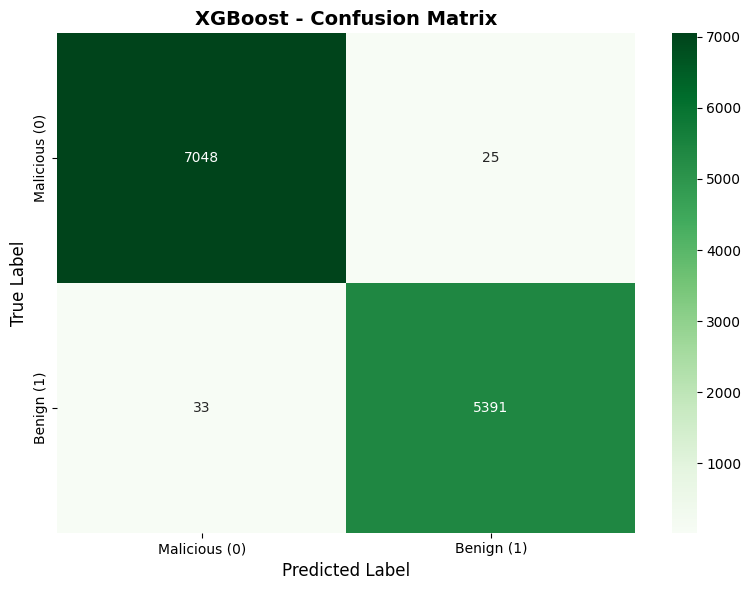


Top 10 Most Important Features (XGBoost):
               Feature  Importance
1            DebugSize    0.266008
12  DllCharacteristics    0.259320
4       MajorOSVersion    0.237162
0              Machine    0.102359
13        ResourceSize    0.048922
2             DebugRVA    0.017141
8   MajorLinkerVersion    0.016295
3    MajorImageVersion    0.013758
10    NumberOfSections    0.012785
6           ExportSize    0.005775


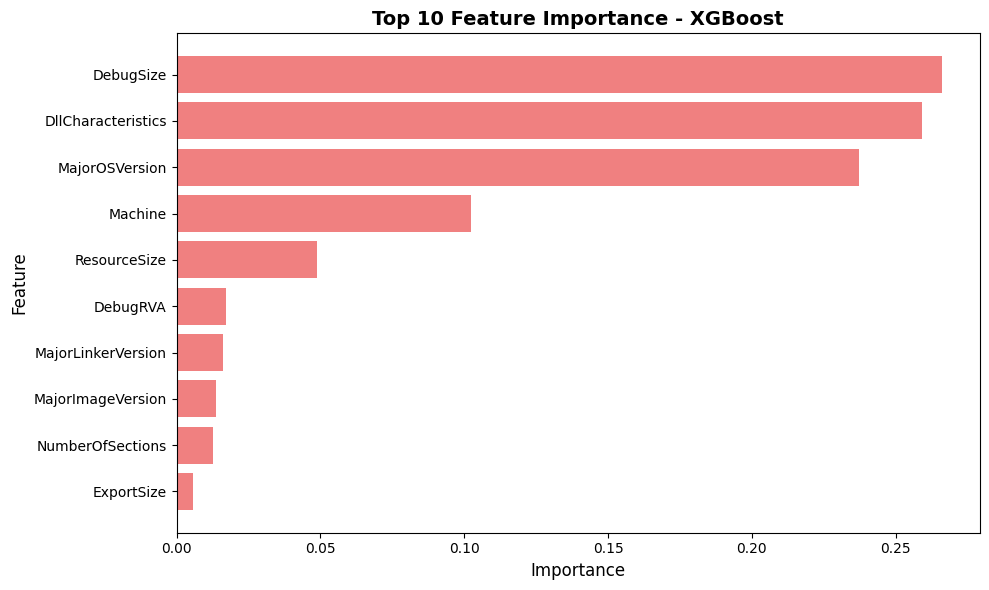

In [8]:
# STEP 8: MODEL TRAINING - XGBOOST
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("MODEL 2: XGBOOST CLASSIFIER")
print("="*70)

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

print("\nTraining XGBoost Classifier...")
xgb_model.fit(X_train_scaled, y_train)
print("✓ XGBoost training completed")

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Calculate metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("\n" + "-"*70)
print("XGBOOST PERFORMANCE METRICS")
print("-"*70)
print(f"Accuracy:  {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(xgb_cm)

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Malicious (0)', 'Benign (1)']))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Malicious (0)', 'Benign (1)'],
            yticklabels=['Malicious (0)', 'Benign (1)'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(10))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb['Feature'].head(10),
         feature_importance_xgb['Importance'].head(10),
         color='lightcoral')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


MODEL COMPARISON

         Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.996399   0.996859 0.994838  0.995848
      XGBoost  0.995359   0.995384 0.993916  0.994649


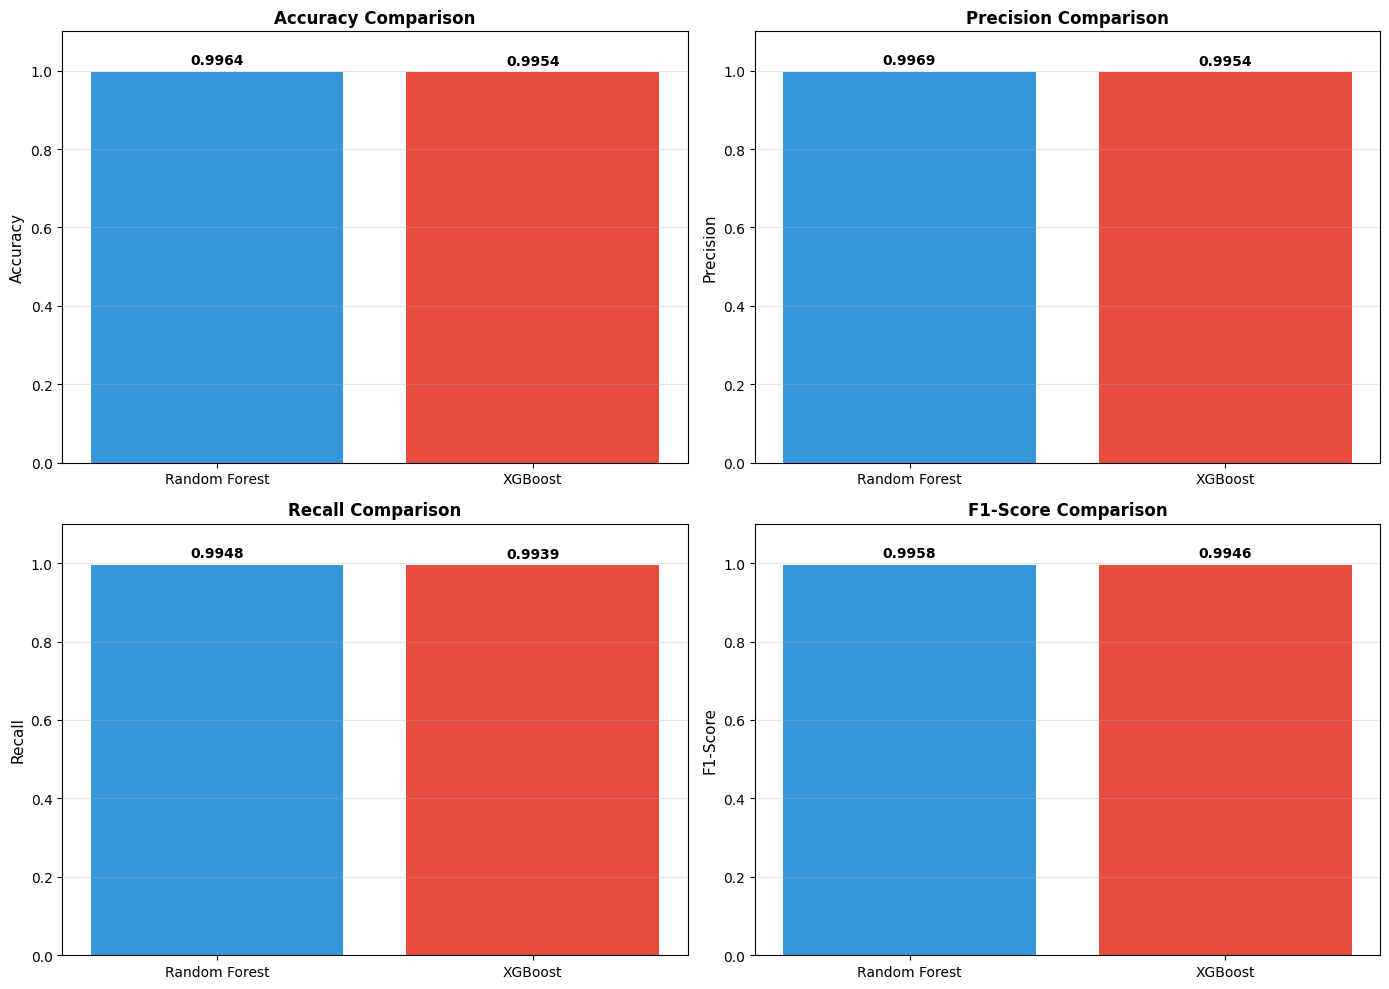


BEST MODEL SELECTION

🏆 Selected Model: Random Forest

Performance Summary:
  • Accuracy:  0.9964 (99.64%)
  • Precision: 0.9969
  • Recall:    0.9948
  • F1-Score:  0.9958


In [9]:
# STEP 9: MODEL COMPARISON AND SELECTION
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Precision': [rf_precision, xgb_precision],
    'Recall': [rf_recall, xgb_recall],
    'F1-Score': [rf_f1, xgb_f1]
})

print("\n", comparison_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Select best model based on F1-Score (balanced metric)
if rf_f1 >= xgb_f1:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy
    best_precision = rf_precision
    best_recall = rf_recall
    best_f1 = rf_f1
else:
    best_model = xgb_model
    best_model_name = "XGBoost"
    best_accuracy = xgb_accuracy
    best_precision = xgb_precision
    best_recall = xgb_recall
    best_f1 = xgb_f1

print("\n" + "="*70)
print("BEST MODEL SELECTION")
print("="*70)
print(f"\n🏆 Selected Model: {best_model_name}")
print(f"\nPerformance Summary:")
print(f"  • Accuracy:  {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"  • Precision: {best_precision:.4f}")
print(f"  • Recall:    {best_recall:.4f}")
print(f"  • F1-Score:  {best_f1:.4f}")

In [10]:
# STEP 10: SAVE THE FINAL MODEL AND SCALER
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("SAVING FINAL MODEL")
print("="*70)

# Save the best model
model_filename = 'ransomware_detection_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\n✓ Model saved as: {model_filename}")

# Save the scaler (CRITICAL for real-time predictions)
scaler_filename = 'feature_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved as: {scaler_filename}")

# Save feature names (for consistency in real-time scanning)
feature_names_filename = 'feature_names.pkl'
joblib.dump(list(X.columns), feature_names_filename)
print(f"✓ Feature names saved as: {feature_names_filename}")

# Save model metadata
metadata = {
    'model_type': best_model_name,
    'accuracy': best_accuracy,
    'precision': best_precision,
    'recall': best_recall,
    'f1_score': best_f1,
    'features': list(X.columns),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_filename = 'model_metadata.pkl'
joblib.dump(metadata, metadata_filename)
print(f"✓ Metadata saved as: {metadata_filename}")

# Download files to local machine
print("\n" + "="*70)
print("DOWNLOAD FILES")
print("="*70)
print("\nDownloading trained model and supporting files...")

files.download(model_filename)
files.download(scaler_filename)
files.download(feature_names_filename)
files.download(metadata_filename)

print("\n✓ All files downloaded successfully!")


SAVING FINAL MODEL

✓ Model saved as: ransomware_detection_model.pkl
✓ Scaler saved as: feature_scaler.pkl
✓ Feature names saved as: feature_names.pkl
✓ Metadata saved as: model_metadata.pkl

DOWNLOAD FILES



NameError: name 'files' is not defined

In [11]:
# STEP 11: MODEL LOADING TEST (VERIFICATION)
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("MODEL LOADING VERIFICATION")
print("="*70)

# Load the saved model and test
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
loaded_features = joblib.load(feature_names_filename)

print("\n✓ Model loaded successfully")
print("✓ Scaler loaded successfully")
print("✓ Feature names loaded successfully")

# Test prediction on a sample
sample_data = X_test.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample_data)
sample_prediction = loaded_model.predict(sample_scaled)

print(f"\nSample Prediction Test:")
print(f"  Input features shape: {sample_data.shape}")
print(f"  Prediction: {'Benign' if sample_prediction[0] == 1 else 'Malicious'}")
print(f"  Actual: {'Benign' if y_test.iloc[0] == 1 else 'Malicious'}")

# ----------------------------------------------------------------------------
# PROJECT SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"""
✓ Dataset loaded and preprocessed
✓ {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples
✓ {len(X.columns)} features used for training
✓ Two models trained and evaluated:
  • Random Forest: F1-Score = {rf_f1:.4f}
  • XGBoost: F1-Score = {xgb_f1:.4f}
✓ Best model selected: {best_model_name}
✓ Model, scaler, and metadata saved for deployment

📁 Files saved:
  1. {model_filename} - Trained ML model
  2. {scaler_filename} - Feature scaler
  3. {feature_names_filename} - Feature column names
  4. {metadata_filename} - Model metadata

🚀 Next Steps:
  • Use saved model for real-time PE file scanning
  • Integrate with path-based detection system
  • Deploy in cybersecurity monitoring pipeline

Project completed successfully! ✨
""")

print("="*70)


MODEL LOADING VERIFICATION

✓ Model loaded successfully
✓ Scaler loaded successfully
✓ Feature names loaded successfully

Sample Prediction Test:
  Input features shape: (1, 15)
  Prediction: Malicious
  Actual: Malicious

PROJECT SUMMARY

✓ Dataset loaded and preprocessed
✓ 49988 training samples, 12497 testing samples
✓ 15 features used for training
✓ Two models trained and evaluated:
  • Random Forest: F1-Score = 0.9958
  • XGBoost: F1-Score = 0.9946
✓ Best model selected: Random Forest
✓ Model, scaler, and metadata saved for deployment

📁 Files saved:
  1. ransomware_detection_model.pkl - Trained ML model
  2. feature_scaler.pkl - Feature scaler
  3. feature_names.pkl - Feature column names
  4. model_metadata.pkl - Model metadata

🚀 Next Steps:
  • Use saved model for real-time PE file scanning
  • Integrate with path-based detection system
  • Deploy in cybersecurity monitoring pipeline

Project completed successfully! ✨



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
